<a href="https://colab.research.google.com/github/winarwahyuw/data-science-250401020025-winar-wahyu-wulansari/blob/main/Data_Science_Pertemuan_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## PERTEMUAN 4
#### Nama : Winar Wahyu Wulansari
#### NIM : 250401020025
#### Kelas : IF405


In [1]:
# Impor library utama yang digunakan dalam modul
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Library berhasil diimpor!")

Library berhasil diimpor!


In [2]:
# Muat dataset iris menggunakan seaborn
df = sns.load_dataset('iris')

# Tampilkan bentuk (shape), tipe data, data teratas, dan deskripsi statistik awal
print('Shape dataset:', df.shape)
print("\n--- Tipe Data Kolom ---")
print(df.dtypes)

print("\n--- 5 Data Teratas (Head) ---")
print(df.head())

print("\n--- Ringkasan Statistik (.describe) ---")
print(df.describe().round(3))

Shape dataset: (150, 5)

--- Tipe Data Kolom ---
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

--- 5 Data Teratas (Head) ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

--- Ringkasan Statistik (.describe) ---
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
5

In [3]:
# Loop untuk menghitung statistik lengkap di setiap kolom numerik
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f' Mean     : {col.mean():.3f}')
    print(f' Median   : {col.median():.3f}')
    print(f' Std Dev  : {col.std():.3f}')
    print(f' Skewness : {col.skew():.3f}')
    print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean     : 5.843
 Median   : 5.800
 Std Dev  : 0.828
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean     : 3.057
 Median   : 3.000
 Std Dev  : 0.436
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean     : 3.758
 Median   : 4.350
 Std Dev  : 1.765
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean     : 1.199
 Median   : 1.300
 Std Dev  : 0.762
 Skewness : -0.103
 Kurtosis : -1.341


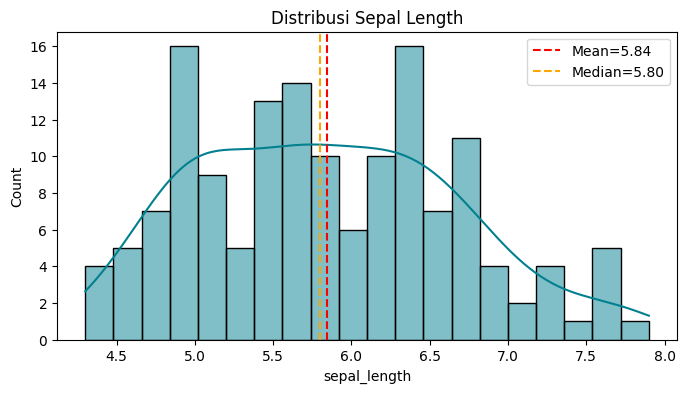

In [4]:
# Membuat visualisasi histogram + KDE sepal_length
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)

# Menambahkan garis bantu penanda nilai Mean dan Median
ax.axvline(df['sepal_length'].mean(), color='red', linestyle='--',
           label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange', linestyle='--',
           label=f"Median={df['sepal_length'].median():.2f}")

ax.set_title('Distribusi Sepal Length')
ax.legend()
plt.show()

/tmp/ipykernel_3618/1493289662.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
/tmp/ipykernel_3618/1493289662.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])


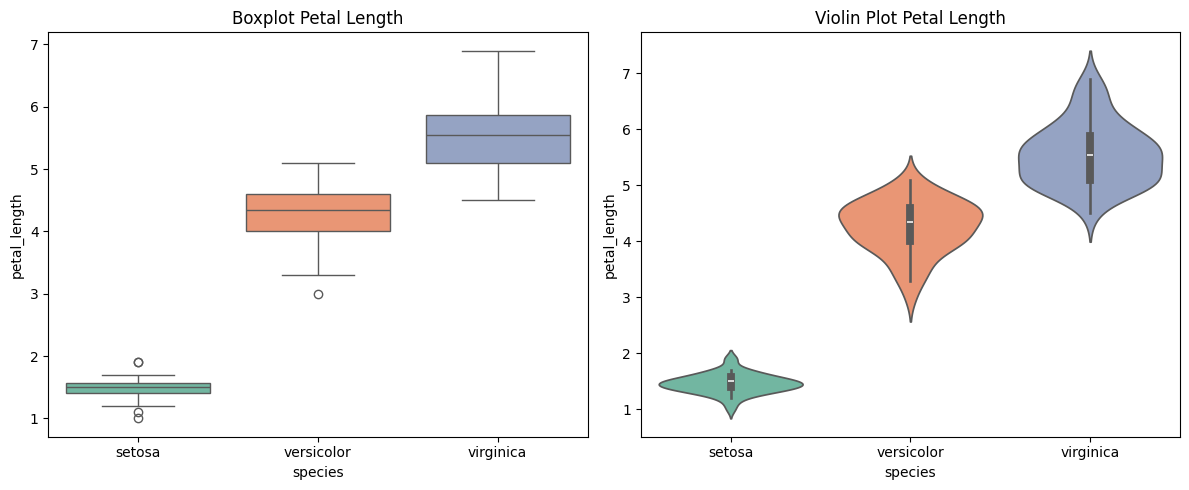

In [5]:
# Membuat subplot berpasangan: Boxplot dan Violin Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot petal_length per spesies
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length')

# Violin plot petal_length per spesies
sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

In [6]:
# Hitung matriks korelasi Pearson dengan mendrop kolom kategorik 'species'
corr = df.drop('species', axis=1).corr(method='pearson')
print("--- Matriks Korelasi Pearson ---")
print(corr.round(3))
print("\n")

# Logika masking untuk mencari pasangan kolom dengan korelasi tertinggi
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()

print(f'Korelasi tertinggi ditemukan pada pasangan: {max_pair} = {corr.loc[max_pair]:.3f}')

--- Matriks Korelasi Pearson ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


Korelasi tertinggi ditemukan pada pasangan: ('petal_width', 'petal_length') = 0.963


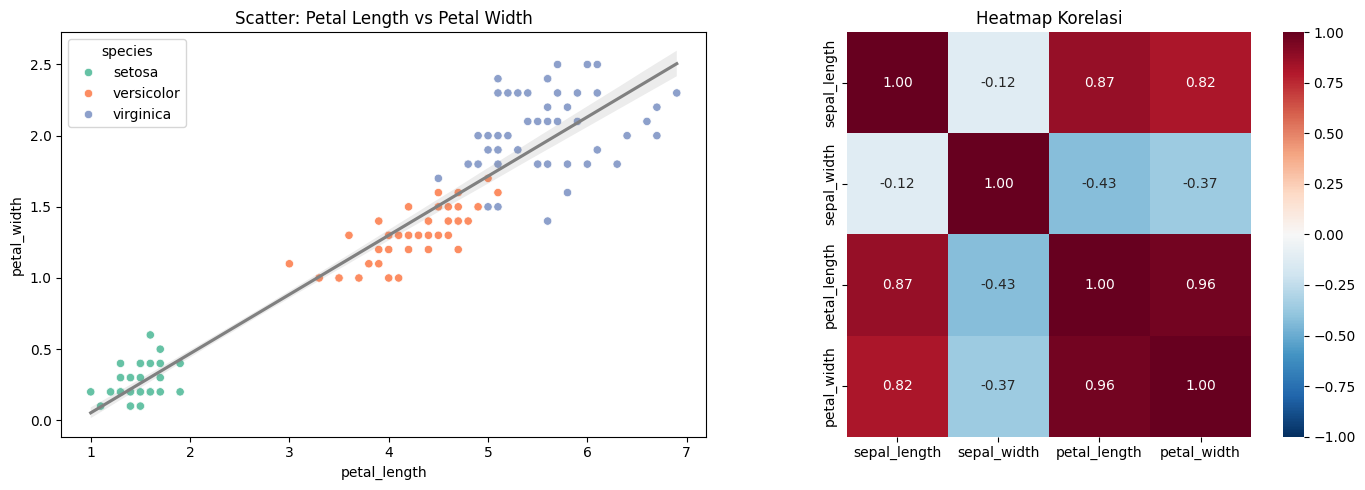

In [7]:
# Membuat visualisasi bivariat akhir
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter Plot: Petal Length vs Petal Width
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')

# 2. Heatmap Korelasi
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

## Kesimpulan & Analisis Eksplorasi Data

### 1. Analisis Ringkasan Data & Distribusi
* **Ukuran Kelopak (`sepal_length` & `sepal_width`)**: Memiliki nilai rata-rata dan median yang sangat dekat, dengan tingkat kemiringan (*skewness*) di kisaran -0.5 hingga 0.5. Hal ini menunjukkan bahwa ukuran kelopak tanaman terdistribusi secara normal atau simetris, sesuai dengan pola kurva lonceng yang terlihat pada histogram.
* **Ukuran Mahkota (`petal_length` & `petal_width`)**: Memiliki tingkat penyebaran data (*standard deviasi*) yang tinggi serta nilai keruncingan (*kurtosis*) yang sangat negatif (-1.402 dan -1.340). Angka ini menjadi indikasi kuat bahwa ukuran mahkota memiliki bentuk distribusi Bimodal (dua puncak terpisah) , karena adanya perbedaan ukuran yang cukup kontras antar jenis spesies di dalam data.

### 2. Karakteristik Ukuran Berdasarkan Spesies
Melalui pengamatan grafik Boxplot dan Violin Plot, variasi ukuran mahkota bunga menunjukkan pola pengelompokan yang jelas:
* **Iris Setosa**: Memiliki ukuran mahkota yang paling kecil dan cenderung seragam (datanya mengumpul rapat di area bawah grafik).
* **Iris Virginica**: Memiliki ukuran mahkota yang paling besar (datanya mengumpul di area atas grafik).
* **Iris Versicolor**: Berada di posisi menengah, namun memiliki rentang kotak (*Interquartile Range*) yang paling lebar. Ini menandakan variasi ukuran pada spesies ini adalah yang paling dinamis.

### 3. Hubungan Antar Variabel (Korelasi & Scatter Plot)
* **Hubungan Terkuat**: Ditemukan pada pasangan sesama ukuran mahkota, yaitu antara panjang dan lebar mahkota dengan nilai korelasi mencapai 0.963.Nilai yang mendekati +1 ini menunjukkan hubungan linear positif yang sangat kuat; artinya saat mahkota tumbuh memanjang, ukurannya juga pasti akan melebar secara proporsional.
* **Hubungan Terlemah**: Terjadi pada pasangan panjang dan lebar kelopak (`sepal_length` & `sepal_width`) dengan nilai -0.118. Angka yang mendekati 0 ini menandakan hampir tidak ada hubungan linear sama sekali di antara keduanya.
* **Pola Pengelompokan**: Grafik Scatter Plot memperlihatkan bahwa titik-titik data terpisah secara visual berdasarkan jenis spesiesnya. Karakteristik ukuran mahkota merupakan pembeda paling akurat yang bisa diandalkan untuk mengelompokkan jenis bunga Iris secara tepat.